In [1]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:

# Define paths
zip_path = "/content/drive/My Drive/archive (8).zip"  # Change this
extract_path = "/content/unzipped_folder"  # Destination folder in Colab

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List extracted files
print("Unzipping done! Extracted files:")
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))



Unzipping done! Extracted files:
/content/unzipped_folder/Positive/14896_1.jpg
/content/unzipped_folder/Positive/07121.jpg
/content/unzipped_folder/Positive/05507.jpg
/content/unzipped_folder/Positive/04247.jpg
/content/unzipped_folder/Positive/19789.jpg
/content/unzipped_folder/Positive/05974.jpg
/content/unzipped_folder/Positive/02003.jpg
/content/unzipped_folder/Positive/09066.jpg
/content/unzipped_folder/Positive/09649.jpg
/content/unzipped_folder/Positive/06169.jpg
/content/unzipped_folder/Positive/00403.jpg
/content/unzipped_folder/Positive/19848.jpg
/content/unzipped_folder/Positive/13148_1.jpg
/content/unzipped_folder/Positive/00770.jpg
/content/unzipped_folder/Positive/05559.jpg
/content/unzipped_folder/Positive/03930.jpg
/content/unzipped_folder/Positive/07521.jpg
/content/unzipped_folder/Positive/06709.jpg
/content/unzipped_folder/Positive/02775.jpg
/content/unzipped_folder/Positive/07837.jpg
/content/unzipped_folder/Positive/17606_1.jpg
/content/unzipped_folder/Positive/185

In [8]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

Found 32000 images belonging to 2 classes.
Found 8000 images belonging to 2 classes.


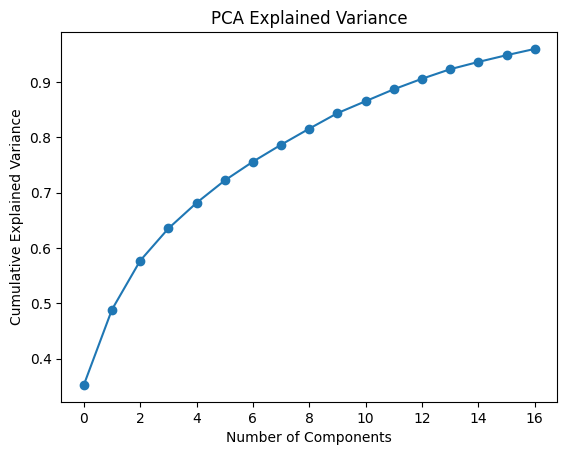

Feature Importances Computed.


In [9]:

# Define paths
base_dir = '/content/unzipped_folder'  # Update if necessary
positive_dir = os.path.join(base_dir, 'positive')  # Cracks present
negative_dir = os.path.join(base_dir, 'negative')  # No cracks

# Image parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Data Augmentation
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2, rotation_range=20,
                                   width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2,
                                   zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

# Extract features and labels
X_train, y_train = next(train_generator)
X_val, y_val = next(val_generator)

# Flatten images for PCA analysis
X_train_flattened = X_train.reshape(X_train.shape[0], -1)
X_val_flattened = X_val.reshape(X_val.shape[0], -1)

# PCA Analysis
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_flattened)
X_val_pca = pca.transform(X_val_flattened)

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

# Decision Tree Feature Importance (Using Flattened Data)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_flattened, y_train)
feature_importances = tree.feature_importances_
print("Feature Importances Computed.")

# Normalize Data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_flattened)
X_val_scaled = scaler.transform(X_val_flattened)

# Label Encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)


In [10]:
# Define Neural Network Model
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_generator, validation_data=val_generator, epochs=5, verbose=1)

# Evaluate Model
y_pred_prob = model.predict(val_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

y_true = val_generator.classes
accuracy = accuracy_score(y_true, y_pred) * 100
print(f"Neural Network Accuracy: {accuracy:.2f}%")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 190s 187ms/step - accuracy: 0.8862 - loss: 0.2789 - val_accuracy: 0.9796 - val_loss: 0.0572
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 186s 186ms/step - accuracy: 0.9737 - loss: 0.0904 - val_accuracy: 0.9761 - val_loss: 0.0686
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 180s 180ms/step - accuracy: 0.9747 - loss: 0.0857 - val_accuracy: 0.9815 - val_loss: 0.0581
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 186s 186ms/step - accuracy: 0.9782 - loss: 0.0719 - val_accuracy: 0.9787 - val_loss: 0.0974
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 178s 178ms/step - accuracy: 0.9831 - loss: 0.0544 - val_accuracy: 0.9921 - val_loss: 0.0421
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 139ms/step
Neural Network Accuracy: 50.00%


TP: 2007, TN: 1993, FP: 2007, FN: 1993


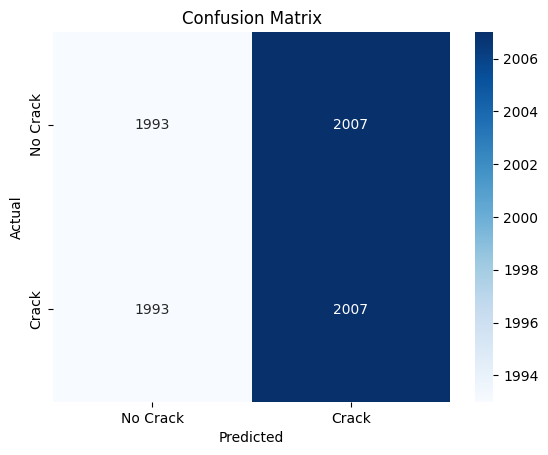

In [11]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
tp = conf_matrix[1, 1]
tn = conf_matrix[0, 0]
fp = conf_matrix[0, 1]
fn = conf_matrix[1, 0]
print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Crack', 'Crack'], yticklabels=['No Crack', 'Crack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()